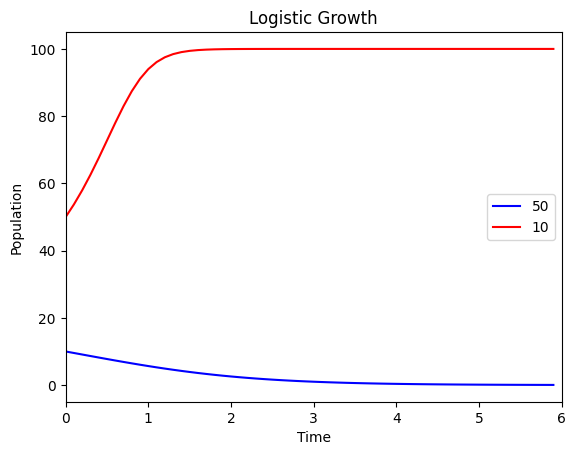

In [23]:
import numpy as np
import matplotlib.pyplot as plt

r = 1
h = 0.1
A = 20
K = 100
n = 6 / h

def dN_dt(N):
    return r * N * (1 - (N / K)) * ((N / A) - 1)

t = np.arange(0, n * h, step=h)

N_e = np.zeros(len(t))
N_e[0] = 10
for i in range(1, len(t)):
    N_e[i] = N_e[i-1] + h * dN_dt(N_e[i-1])
plt.plot(t, N_e, label='50', color='blue')

N_e = np.zeros(len(t))
N_e[0] = 50
for i in range(1, len(t)):
    N_e[i] = N_e[i-1] + h * dN_dt(N_e[i-1])
plt.plot(t, N_e, label='10', color='red')

plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Logistic Growth')
plt.legend()
plt.xlim(0, 6)
plt.show()

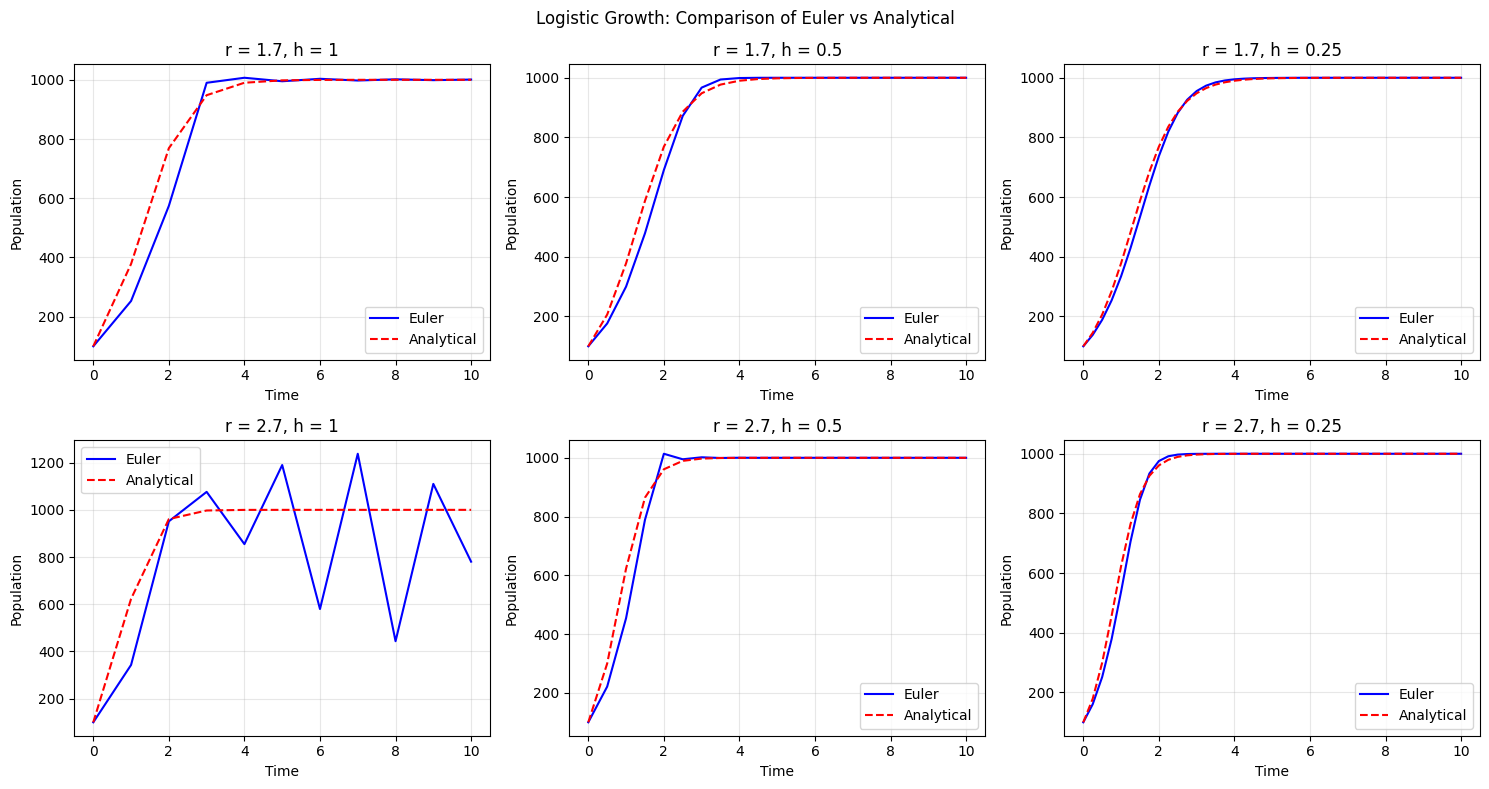

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters to test
r_values = [1.7, 2.7]
h_values = [1, 0.5, 0.25]

def dN_dt(N, r):
    return r * N * (1 - (N / 1000))

def N_analytical(t, r):
    return (1000 * np.exp(r * t)) / (9 + np.exp(r * t))

# Create a figure with subplots: len(r_values) rows, len(h_values) columns
fig, axes = plt.subplots(nrows=len(r_values), ncols=len(h_values), 
                         figsize=(5*len(h_values), 4*len(r_values)))
fig.suptitle("Logistic Growth: Comparison of Euler vs Analytical")

# For each combination of r and h
for i, r in enumerate(r_values):
    for j, h in enumerate(h_values):
        ax = axes[i, j]
        
        # Time vector - go up to t = 10 for consistency
        t_max = 10
        n_steps = int(t_max / h) + 1
        t = np.linspace(0, t_max, n_steps)

        # Euler method
        N_e = np.zeros(len(t))
        N_e[0] = 100
        for k in range(1, len(t)):  # Changed variable name from 'i' to 'k'
            N_e[k] = N_e[k-1] + h * dN_dt(N_e[k-1], r)

        # Analytical solution
        N_a = N_analytical(t, r)

        # Plot
        ax.plot(t, N_e, label='Euler', color='blue')
        ax.plot(t, N_a, label='Analytical', color='red', linestyle='--')
        ax.set_title(f'r = {r}, h = {h}')
        ax.set_xlabel('Time')
        ax.set_ylabel('Population')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()